<a href="https://colab.research.google.com/github/Matej-Vylet/MPA-MLF/blob/main/pc3_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

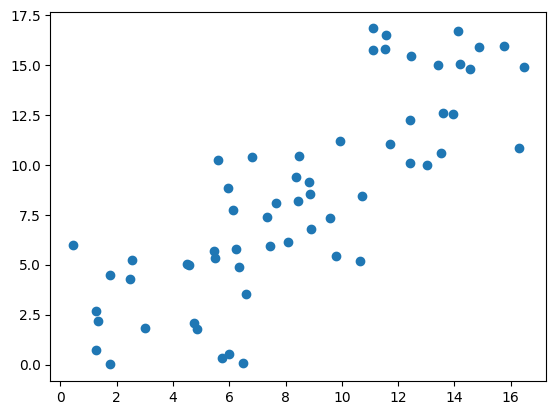

In [ ]:
import matplotlib.pyplot as plt
import copy
import numpy as np
from numpy.linalg import norm
from sklearn.cluster import KMeans

loaded_points = np.load('k_mean_points.npy')

plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])

k = 3



In [ ]:
def initialize_clusters(points: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Initializes and returns k random centroids from the given dataset.

    :param points: Array of data points.
    :type: points ndarray with shape (n, 2)

    :param k_clusters: The number of clusters to form
    :type k_clusters: int


    :return: initial_clusters
    initial_clusters: Array of initialized centroids

    :rtype:
    initial_clusters: np.array (k_clusters, 2)
    :

    """

    ###################################
    # Write your own code here #
    initial_clusters = points[np.random.choice(points.shape[0], size=k_clusters, replace=False),:]


    ###################################

    return initial_clusters

In [ ]:
ini_clusters = initialize_clusters(loaded_points, k)
print(ini_clusters)

[[ 6.57977375  3.55640765]
 [14.13036356 16.72446994]
 [ 8.47585415 10.47009155]]


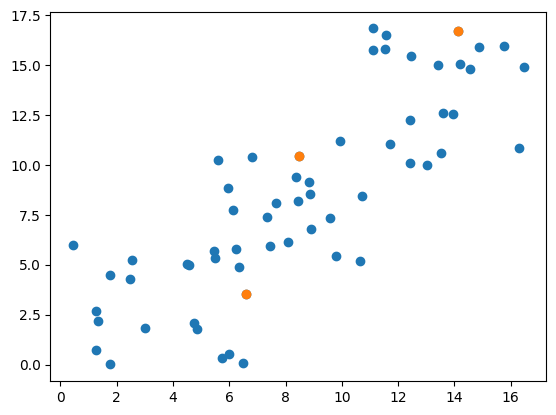

In [ ]:
plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])
plt.scatter(ini_clusters[:, 0], ini_clusters[:, 1])

In [ ]:
def calculate_metric(points: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    """
    Calculates the distance metric between each point and a given centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroid: A single centroid
    :type centroid: ndarray with shape (1, 2)

    :return: distances_array
    distances_array: Array of distances from point to centroid

    :rtype:
    distances_array: ndarray with shape (n,)
    :
    """

    ###################################
    # Write your own code here #

    distances_array = np.square(norm(points-centroid, axis=1))
    #distances_array = norm(points-centroid, axis=1)


    ###################################

    return distances_array

In [ ]:
metrics=calculate_metric(loaded_points, ini_clusters[2])
print(metrics)

[ 88.49711765  51.39414592  31.84141024  35.26164269  35.68975002
  84.42784062  83.94510085  45.35417946  62.33380999 146.88420247
 154.3871949  109.96983341 104.03363116 111.3071596  112.26246189
 119.49180509  74.08651943  80.69405229 104.3434092   45.32742766
   1.17515951  10.84841673   2.77583655   8.26475071  10.87579586
   1.81188249  12.86035356   9.1615414    6.29404427   5.166528
  32.51062853   2.67041703  27.07897574  26.81945059  21.77532231
  13.85307895   8.98292095   0.           3.91718267  18.79752855
  46.27631515  83.588826    40.64870945  44.8966646   30.63924258
  71.09072584  34.19831843  18.85235767  25.34857041  15.62900772
  21.04479517  53.75192234  55.7548194   34.75155016  61.35827736
  38.23263413  70.54910657  83.40152787  47.58814508  10.82862106]


In [ ]:
def compute_distances(points: np.ndarray, centroids_points: np.ndarray) -> np.ndarray:
    """
    Computes and returns the distance from each point to each centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroids_points: A all centroid points
    :type centroids_points: ndarray with shape (k_clusters, 2)


    :return: distances_array
    distances_array: 2D array with distances of each point to each centroid.

    :rtype:
    distances_array: ndarray of shape (k_clusters, n)
    """
    ###################################
    # Write your own code here #

    distance_list = []
    for centroid in centroids_points:
      distances = calculate_metric(points, centroid)
      distance_list.append(distances)

    distances_array = np.asarray(distance_list)
    ###################################

    return distances_array

In [ ]:
distances = compute_distances(loaded_points, ini_clusters)
print(distances)

[[  6.11124205   0.           5.84002644   4.38155886   1.83355826
   43.45077965   5.49465166   6.4942718   19.24048983  36.17526251
   35.7064104   11.00765375  15.63652402  11.90757634  28.86296239
   29.31145848  17.51575814  24.04421632   9.31739117   6.17458392
   37.28077074  15.16958501  46.91402391  45.90868046  23.54086054
   36.59893356  17.71514436  41.08230914  21.78649057  24.95347338
   19.12485161  69.75445175  13.81056949   5.16453648   6.32571459
   15.770333    28.57921127  51.39414592  30.01747158   9.01349987
  193.15853016 226.69310858 176.11339993 177.73788437 130.69526496
  230.40927108 135.13000066 109.9050354   97.58344756  76.94891432
   83.54310235 190.07989758 189.96961822 169.07926759 147.7681282
  175.50943201 221.45226704 238.60975218 197.12535456  82.44625479]
 [309.16716726 230.40927108 196.6877671  204.3466081  200.70378415
  302.28367497 301.93403783 229.39632302 265.66934063 421.3499016
  432.15632405 338.6940534  344.66424333 334.38076406 362.01127

In [ ]:
def assign_centroids(distances: np.ndarray) -> np.ndarray:
    """
    Assigns each point to the closest centroid based on the distances.

    Parameters:
    :param distances: 2D array with distances of each point to each centroid.
    :type distances: ndarray with shape (k_clusters, n)

    :return: assigned_clusters
    assigned_clusters: Array indicating the closest centroid for each data point.

    :rtype:
    assigned_centroids: ndarray with shape (1, n) and dtype = np.int32
    """

    ###################################
    # Write your own code here #

    assigned_centroids = np.argmin(distances, axis = 0)
    ###################################

    return assigned_centroids

In [ ]:
assigned_centroids = assign_centroids(distances)
print(assigned_centroids)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 2 2
 2 2 0 1 1 1 1 1 1 1 2 2 2 2 1 1 1 1 1 1 1 1 2]


In [ ]:
def calculate_objective(assigned_centroids: np.ndarray, distances: np.ndarray) -> np.ndarray:
    """
    Calculates and returns the objective function value for the clustering.

    Parameters:
    :param assigned_centroids: Array indicating the cluster assignment for each point.
    :type assigned_centroids: ndarray with shape (1, n) and and dtype = np.int64

    :param distances: 2D array with distances of each point to each centroid
    :type distances: ndarray with shape (k_clusters, n) and and dtype = np.float64

    :return: onjective_function_value
    onjective_function_value: Objective function value.

    :rtype:
    onjective_function_value: float32


    """
    ###################################
    # Write your own code here #

    distances = distances.T
    selectedMin = distances[np.arange(len(distances)), assigned_centroids]

    ###################################

    return np.sum(selectedMin)

In [ ]:
calc_obj = calculate_objective(assigned_centroids, distances)
print(calc_obj)

697.4489486801085


In [ ]:
def calculate_new_centroids(points: np.ndarray, assigned_centroids: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Computes new centroids based on the current cluster assignments.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param assigned_centroids: Array indicating the closest centroid for each data point.
    :type assigned_centroids: ndarray with shape (1, n) and dtype = np.int32


    :param k_clusters: Number of clusters.
    :type k_clusters: int


    :return: new_clusters
    new_clusters: new cluster points

    :rtype:
    new_clusters: ndarray with shape (1, n) and dtype = np.float32
    """

    ###################################
    # Write your own code here #

    new_clusters = []
    for clusterID in range(k_clusters):
        x = np.where(assigned_centroids == clusterID)
        pointSelect = points[x]
        new_clusters.append(np.mean(pointSelect, axis = 0))

    ###################################

    return new_clusters

In [ ]:
calc_new_centroids = calculate_new_centroids(loaded_points, assigned_centroids, k)
print(calc_new_centroids)

[array([4.75332462, 3.61842759]), array([13.66745571, 14.98568409]), array([9.23942   , 9.31563166])]


In [ ]:
def fit(points: np.ndarray, k_clusters: int, n_of_operations: int, error: float = 0.001) -> tuple:
    """
    Fits the k-means clustering model on the dataset.

    Parameters:
    :param points : Array of data points.
    :type points: ndarray with shape (n, 2) and dtype = np.float32

    :param k_clusters:  Number of clusters
    :type k_clusters: int

    :param n_of_oterations:  Maximum number of iterations
    :type n_of_oterations: int


    :param error: Threshold for convergence.
    :type error: float

    :return: centroid_points, last_objective
    centroid_points: final centroid points
    last_objective: final objective funtion

    :rtype:
    centroid_points: ndarray with shape (k_clusters, 2) and dtype = np.float32
    last_objective: float

    """

    ###################################
    # Write your own code here #

    centroid_points = initialize_clusters(points, k_clusters)
    last_objective = 10000
    objective_log = [last_objective]

    for i in range(n_of_operations):
      distances = compute_distances(points, centroid_points)
      cluster_belong = assign_centroids(distances)

      objective = calculate_objective(cluster_belong, distances)
      centroid_points = calculate_new_centroids(points, cluster_belong, k_clusters)
      objective_log.append(last_objective)
      if abs(last_objective - objective)<error:
        break
      last_objective = objective
    return centroid_points, last_objective, cluster_belong, objective_log



[10000, 10000, np.float64(1539.95866319484), np.float64(661.8308344130672), np.float64(476.64714469284013), np.float64(431.71867436498053), np.float64(430.63558221912785)]
Last objective value: 430.63558221912785


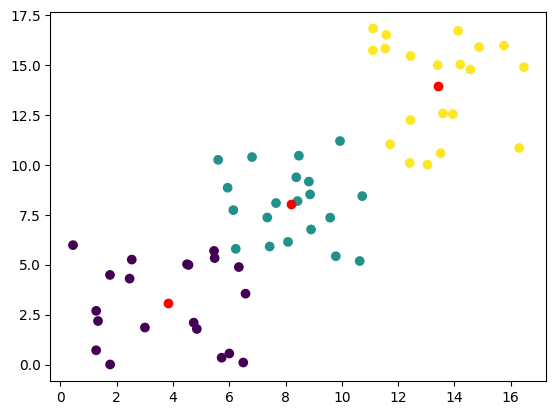

In [ ]:
x, y, z, q = fit(loaded_points, k, 1000)
print(q)
print("Last objective value: " + str(y))
plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1], c = z)
for i in range(3):
  plt.scatter(x[i][0], x[i][1], c= "red")
plt.show()

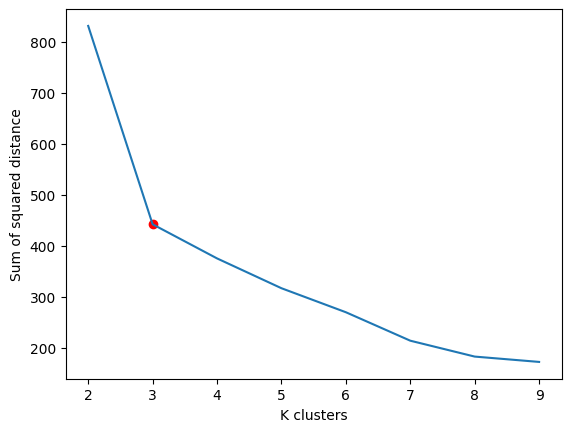

In [ ]:
#elbow method
k_all = range(2, 10)
all_objective = []

for k in k_all:
  all_objective.append(fit(loaded_points, k, 1000)[1])



plt.figure()
plt.plot(k_all, all_objective)
plt.xlabel('K clusters')
plt.ylabel('Sum of squared distance')
plt.scatter(k_all[1], all_objective[1], c = "red")
plt.show()



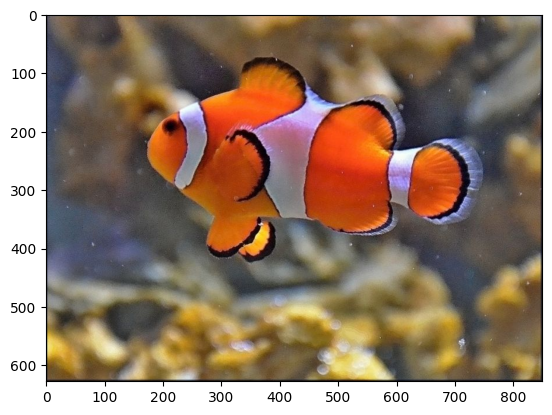

In [ ]:
from matplotlib.image import imread
from sklearn.cluster import KMeans
import numpy as np

loaded_image = imread('fish.jpg')

plt.imshow(loaded_image)
plt.show()

In [ ]:
def compress_image(image: np.array, number_of_colours: int) -> np.array:
    weight, height, channels = image.shape
    image_vector = np.reshape(image, (weight*height, channels))

    kmeans = KMeans(number_of_colours, tol=0.001).fit(image_vector)
    round = kmeans.cluster_centers_.astype(int)
    labels = list(kmeans.labels_)
    compressed = []

    for pixel in range(image_vector.shape[0]):
      compressed.append(round[labels[pixel]])

    image = np.reshape(compressed,(image.shape[0],image.shape[1],3))
    return image

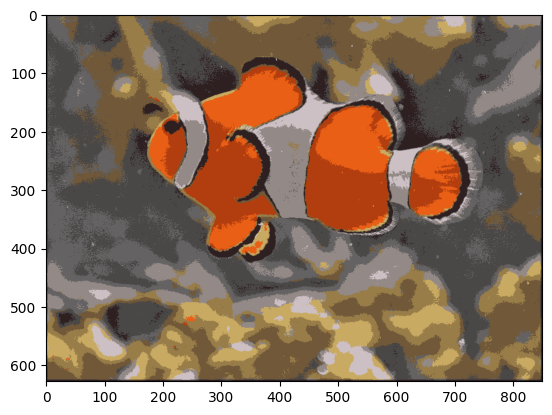

In [ ]:
img = compress_image(loaded_image, 10)

plt.figure()
plt.imshow(img)
plt.show()